# <font color=red>Data Analysis Final Project</font>

-----------------------------------------------------------------------------------------------------
# Used Car Prices Analysis
-----------------------------------------------------------------------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

## Used Car Price Dataset

The used car market plays a crucial role in the car industry, offering buyers a more affordable way to own a vehicle and sellers a chance to recover part of their investment. Buying or selling a car is often a significant financial decision, and understanding the factors that influence price can help both sides make informed choices.

This dataset contains detailed information on various aspects of used cars, including the make year, engine cc, mileage, transmission type, fuel type, accident history, and more. These features not only describe the vehicles but also provide insight into how different attributes contribute to their market value.

By analyzing this data, I can identify patterns, compare pricing trends across different brands, and explore the impact of key factors such as engine size, number of previous owners, and accident history.

In this project, I explore the dataset, draw meaningful conclusions, and build a predictive model that estimates the price range of a used car based on its characteristics.

In [2]:
df = pd.read_csv("used_car_price_dataset_extended.csv")

display(df.head())
display(df.describe())
display(df.describe(include=['O']))
df.info()
display(df.shape)

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


,fuel_type,brand,transmission,color,service_history,insurance_valid
count,10000,10000,10000,10000,7962,10000
unique,3,10,2,6,2,2
top,Petrol,Nissan,Manual,Gray,Full,Yes
freq,4968,1089,5985,1705,4987,7934


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


(10000, 12)

- The sample includes 10,000 records and has 12 features.
- There are 6 numeric variables and 6 categorical variables.
- Only *service_history* has missing values.

## Exploratory Data Analysis

### Visualizing Distributions

Before visualizing the variables, I handle the missing values in *service_history*, the only feature that has them.

Since a missing service history most likely means the car has no service history, I replace the missing values with "None".

In [3]:
df = df.fillna("None")

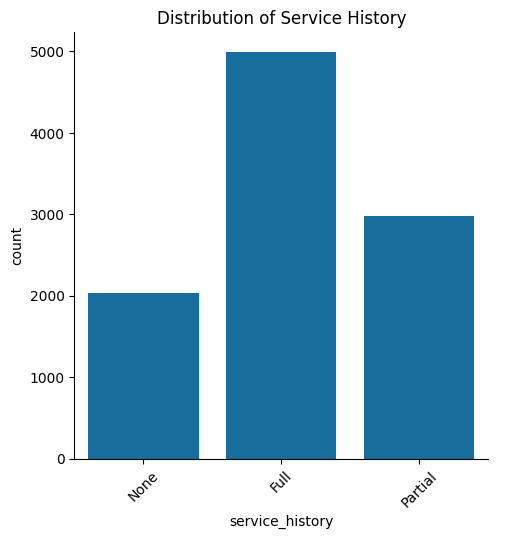

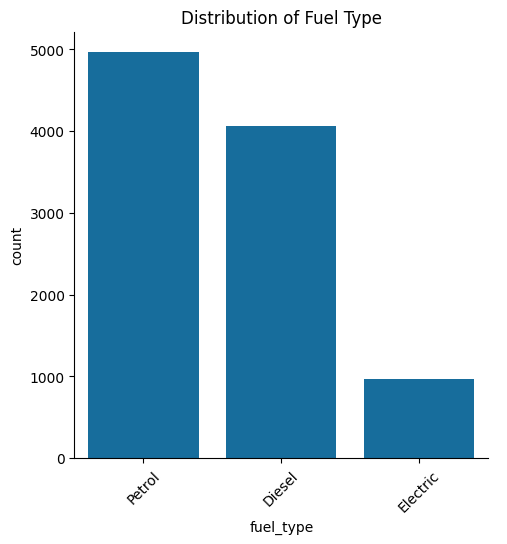

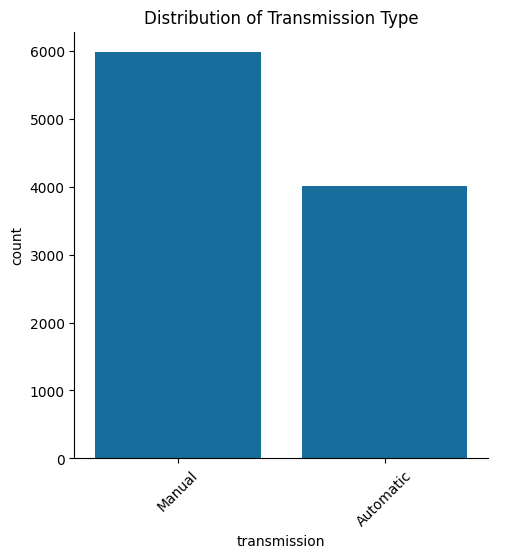

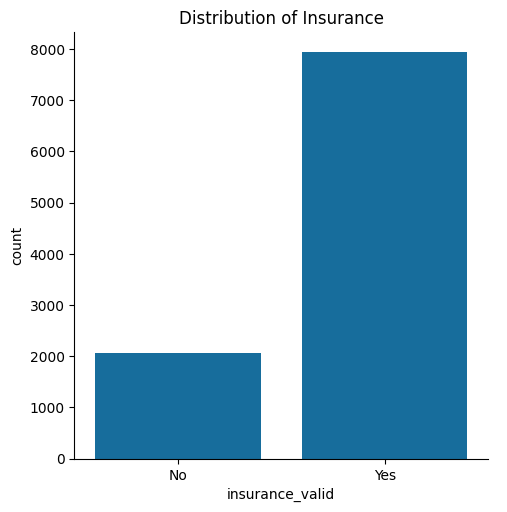

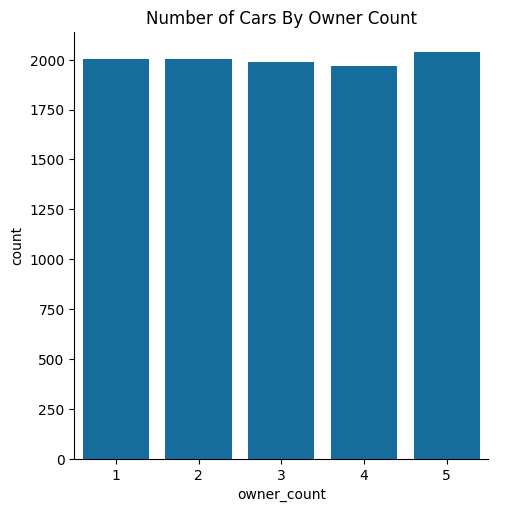

In [4]:
# Distributions of categorical variables
sns.set_palette("colorblind")

# service_history
ax = sns.catplot(data=df, x='service_history', kind='count')
ax.set(title='Distribution of Service History')
plt.xticks(rotation=45)
plt.show()

# fuel_type
ax = sns.catplot(data=df, x='fuel_type', kind='count')
ax.set(title='Distribution of Fuel Type')
plt.xticks(rotation=45)
plt.show()

# transmission
ax = sns.catplot(data=df, x='transmission', kind='count')
ax.set(title='Distribution of Transmission Type')
plt.xticks(rotation=45)
plt.show()

# insurance_valid
ax = sns.catplot(data=df, x='insurance_valid', kind='count')
ax.set(title='Distribution of Insurance')
plt.show()

# owner_count
# owner_count is numeric, but I treat it as categorical since a bar plot makes more sense
ax = sns.catplot(data=df, x='owner_count', kind='count')
ax.set(title = 'Number of Cars By Owner Count')
plt.show()

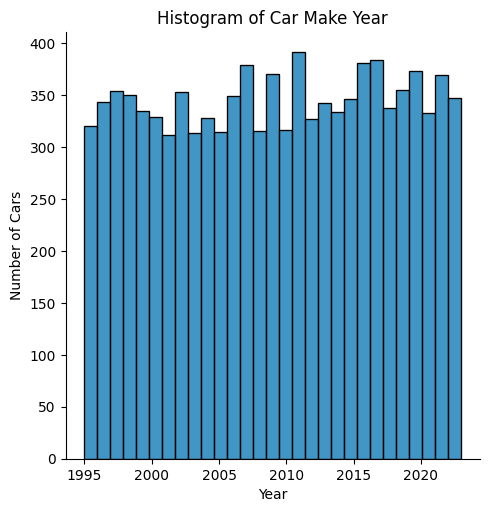

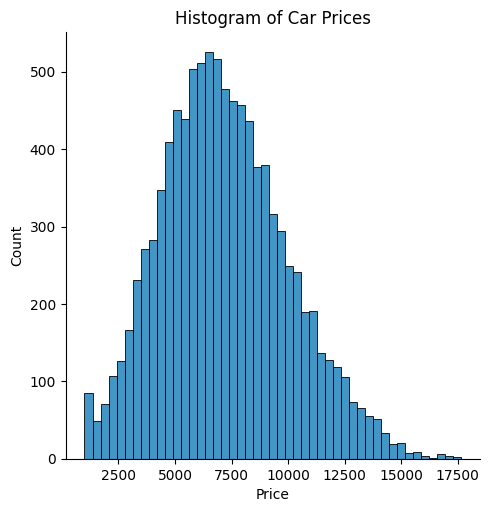

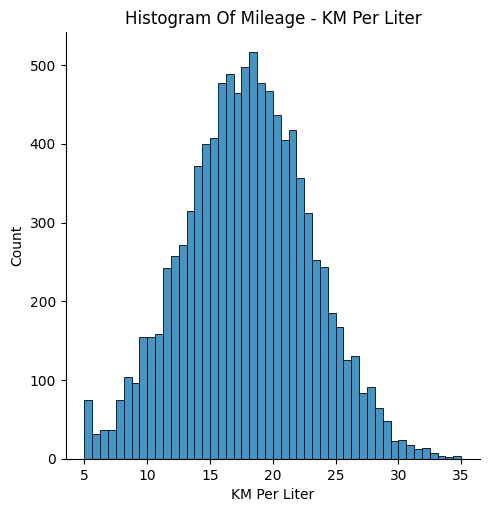

In [5]:
# Distributions of continuous variables

# make_year
ax = sns.displot(df, x='make_year', bins=29)  # One bin per make year (1995-2023)
ax.set(xlabel='Year', ylabel='Number of Cars', title='Histogram of Car Make Year')
plt.show()

# price_usd
ax = sns.displot(df, x='price_usd')
ax.set(xlabel='Price', ylabel='Count', title='Histogram of Car Prices')
plt.show()

# mileage_kmpl
ax = sns.displot(data=df, x='mileage_kmpl')
ax.set(xlabel='KM Per Liter', ylabel='Count', title='Histogram Of Mileage - KM Per Liter')
plt.show()

### Visualizing Relationships

After getting a sense of how the variables are distributed, I look at relationships that may be interesting.

Car price is the focal variable of interest, so I visualize the relationships between *price_usd* and other variables that I think may impact the price:

- Mileage (km/l) vs. price
- Make year vs. price
- Make year vs. engine capacity

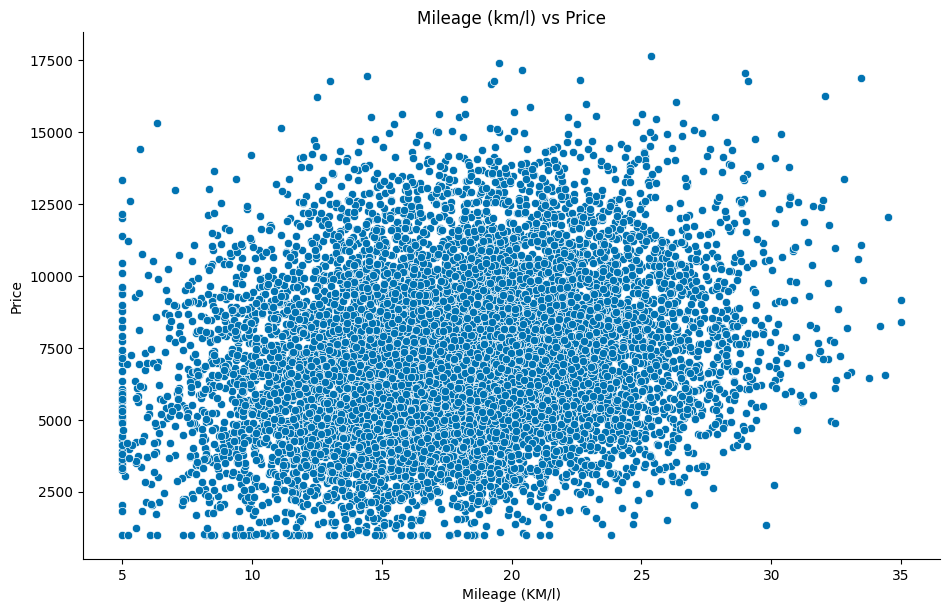

In [6]:
sns.relplot(x="mileage_kmpl", y="price_usd", data=df, height=6, aspect=1.6)
plt.title('Mileage (km/l) vs Price')
plt.xlabel('Mileage (KM/l)')
plt.ylabel('Price')
plt.show()

There seems to be no correlation between km/l and car price.

Since "car price per year" might yield different results using different methods, I create the line plot using both the mean and the median for each year.

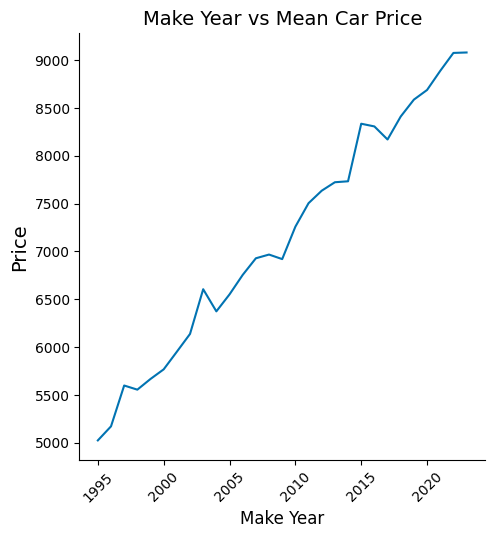

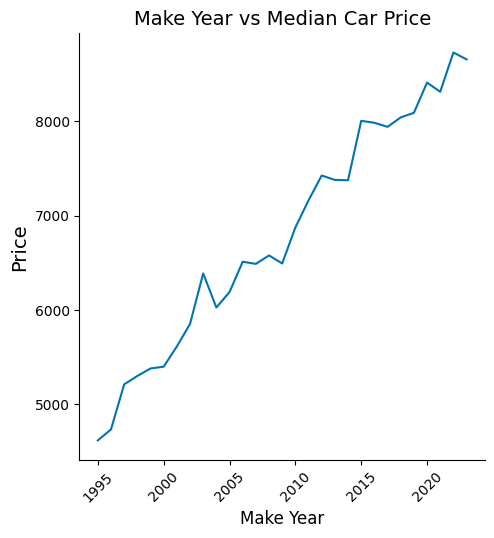

In [7]:
# Mean car price for each year
df_line_mean = df.groupby('make_year')['price_usd'].mean().reset_index()

# Line plot of mean car price by year
sns.relplot(x="make_year", y="price_usd", kind="line", data=df_line_mean)
plt.title('Make Year vs Mean Car Price', fontsize=14)
plt.xlabel('Make Year', fontsize=12)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# Median car price for each year
df_line_median = df.groupby('make_year')['price_usd'].median().reset_index()

# Line plot of median car price by year
sns.relplot(x="make_year", y="price_usd", kind="line", data=df_line_median)
plt.title('Make Year vs Median Car Price', fontsize=14)
plt.xlabel('Make Year', fontsize=12)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45)
plt.show()

Again, since "engine capacity per year" might yield different results using different methods, I create the line plot using both the mean and the median for each year.

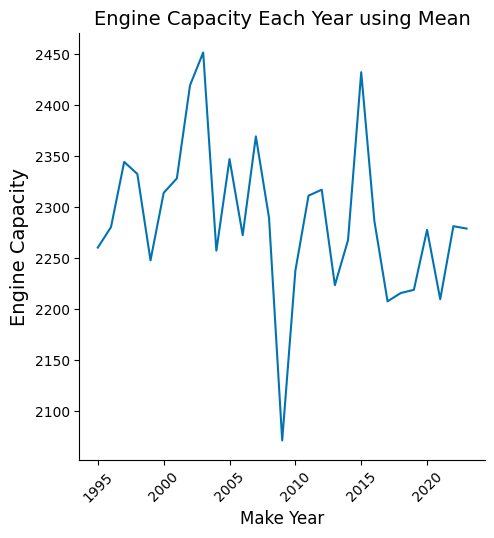

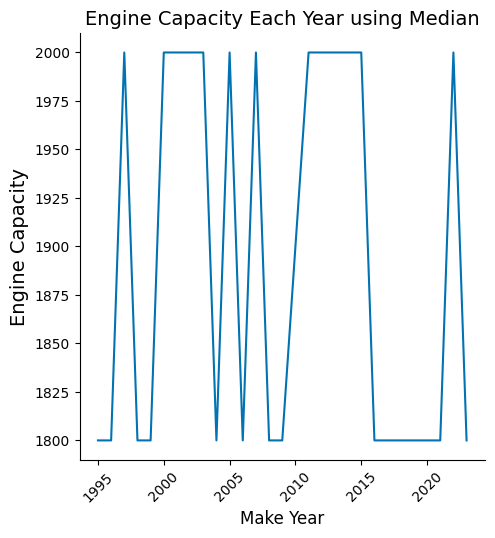

In [8]:
# Mean engine capacity for each year
df_line_mean = df.groupby('make_year')['engine_cc'].mean().reset_index()

# Line plot of mean engine capacity by year
sns.relplot(x="make_year", y="engine_cc", kind="line", data=df_line_mean)
plt.title('Engine Capacity Each Year using Mean', fontsize=14)
plt.xlabel('Make Year', fontsize=12)
plt.ylabel('Engine Capacity', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# Median engine capacity for each year
df_line_median = df.groupby('make_year')['engine_cc'].median().reset_index()

# Line plot of median engine capacity by year
sns.relplot(x="make_year", y="engine_cc", kind="line", data=df_line_median)
plt.title('Engine Capacity Each Year using Median', fontsize=14)
plt.xlabel('Make Year', fontsize=12)
plt.ylabel('Engine Capacity', fontsize=14)
plt.xticks(rotation=45)
plt.show()

## Hypothesis Testing

In this section, I determine whether the selected features - fuel type and transmission type - have a direct relationship with car price.

This question is of interest because these variables can potentially help predict a car's price based on factors I believe are important when purchasing a vehicle.

$H_0$ : There is no relation between the selected variables and car price
$H_1$ : There is a relation between at least one of the selected variables and car price

### Hypothesis Test #1: Does Fuel Type Affect Car Price?

I use a bootstrap method to compute a 95% confidence interval for the difference between the fuel type means.

**Test statistic:**

Since there are 3 groups, the question is whether at least one group mean is different from the others, so I compare the groups in pairs:

(group A mean) - (group B mean), where A, B ∈ {Diesel, Petrol, Electric}

$H_0$ : Fuel type has no effect on car price.

$H_1$ : Fuel type affects car price.

              Pair Observed Diff in Means 95% Confidence Interval  p-value
  Diesel vs Petrol                  27.25        [-84.31, 138.30]   0.6214
Diesel vs Electric               -2931.74    [-3122.08, -2745.90]   0.0000
Electric vs Petrol                2958.99      [2774.96, 3144.66]   0.0000


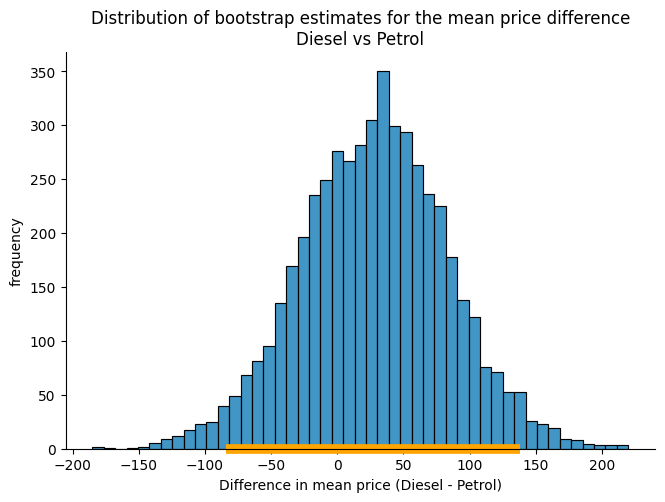

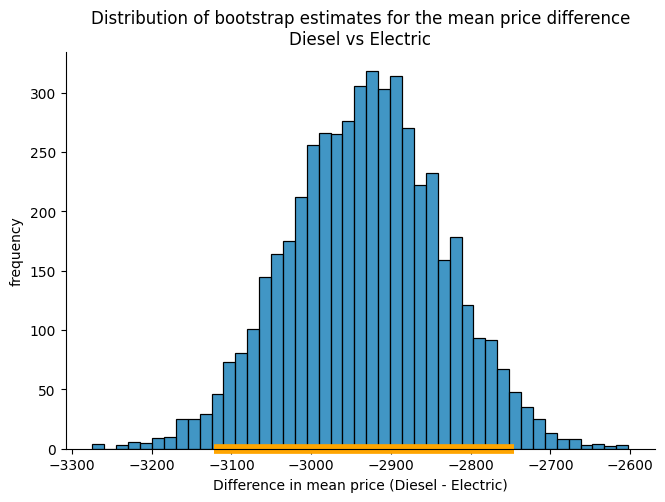

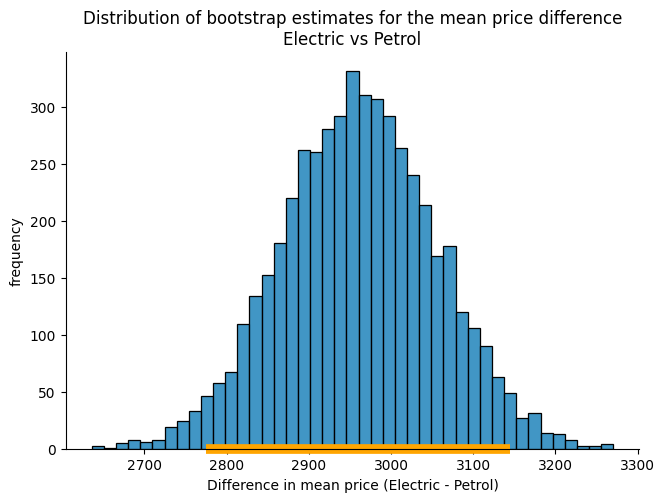

In [ ]:
# Return the difference in averages of column_name between the two groups of grouping_var
def diff_of_avgs(df_in, column_name, grouping_var):
    grpby_var = df_in.groupby(grouping_var, observed=True)
    avgs = grpby_var[column_name].mean()
    # Assumes df_in contains exactly two groups; the result is (second group - first group)
    return avgs.iloc[1] - avgs.iloc[0]

def bootstrap_mean_difference(original_sample, column_name, grouping_var, num_replications):
    '''This function returns an array of bootstrapped differences between two sample averages:
      original_sample: df containing the original sample
      column_name: name of column containing the variable to average
      grouping_var: name of variable according to which to group
      num_replications: number of bootstrap samples'''
    original_sample_size = original_sample.shape[0]  # Resample with the same sample size
    original_sample_cols_of_interest = original_sample[[column_name, grouping_var]]
    bstrap_mean_diffs = np.empty(num_replications)
    for i in range(num_replications):
        # Sample with replacement
        bootstrap_sample = original_sample_cols_of_interest.sample(original_sample_size, replace=True)
        resampled_mean_diff = diff_of_avgs(bootstrap_sample, column_name, grouping_var)
        bstrap_mean_diffs[i] = resampled_mean_diff
    return bstrap_mean_diffs

# Fuel type pairs to compare
pairs = [("Diesel", "Petrol"), ("Diesel", "Electric"), ("Electric", "Petrol")]

# Run the bootstrap for each pair
results = []  # Results for each pair
NUM_REPS = 5000

for g1, g2 in pairs:
    # Keep only the two groups in this pair
    sub_df = df[df['fuel_type'].isin([g1, g2])].copy()

    sub_df['fuel_type'] = pd.Categorical(sub_df['fuel_type'], categories=[g2, g1], ordered=True)

    # Observed difference in means
    obs_diff = diff_of_avgs(sub_df, 'price_usd', 'fuel_type')

    # Bootstrap distribution of the mean differences
    bstrap_diffs = bootstrap_mean_difference(
        original_sample=sub_df,
        column_name='price_usd',
        grouping_var='fuel_type',
        num_replications=NUM_REPS
    )

    # 95% confidence interval
    left_end = np.percentile(bstrap_diffs, 2.5, method='higher')
    right_end = np.percentile(bstrap_diffs, 97.5, method='higher')

    # P-value: the bootstrap distribution is centered at the observed difference, so shift it to be
    # centered at 0 (the null hypothesis) and count how often a difference at least as extreme appears
    null_diffs = bstrap_diffs - obs_diff
    p_value = np.mean(np.abs(null_diffs) >= np.abs(obs_diff))

    # Store results
    results.append({
        'Pair': f'{g1} vs {g2}',
        'Observed Diff in Means': f'{obs_diff:.2f}',
        '95% Confidence Interval': f'[{left_end:.2f}, {right_end:.2f}]',
        'p-value': p_value
    })

    # Plot the bootstrap distribution with the confidence interval
    ax = sns.displot(bstrap_diffs, height=4.5, aspect=1.5)
    plt.hlines(y=0, xmin=left_end, xmax=right_end,
               colors='orange', linestyles='solid', lw=7, clip_on=False)
    ax.set(
        xlabel=f'Difference in mean price ({g1} - {g2})',
        ylabel='frequency',
        title=f'Distribution of bootstrap estimates for the mean price difference\n{g1} vs {g2}'
    )

# Summary table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

### Bootstrap Results

**Diesel vs. Petrol:**
The 95% confidence interval for the difference in mean prices **includes 0**, so I cannot reject the null hypothesis. There is no evidence that the mean prices of Diesel and Petrol cars differ.

**Diesel vs. Electric:**
The 95% confidence interval for the difference in mean prices **does not include 0**, so I reject the null hypothesis and conclude that the mean prices of Diesel and Electric cars differ. Electric cars have a higher mean price, since the difference is *negative*.

**Electric vs. Petrol:**
The 95% confidence interval for the difference in mean prices **does not include 0**, so I reject the null hypothesis and conclude that the mean prices of Electric and Petrol cars differ. Electric cars have a higher mean price, since the difference is *positive*.

The p-values agree with the confidence intervals: Diesel vs. Petrol has a large p-value, while both comparisons with Electric have a p-value of (practically) 0.

**Conclusion:** I reject the null hypothesis. Fuel type clearly affects price, with Electric cars having a higher price.

To see the difference more clearly, I plot the average car price per fuel type.

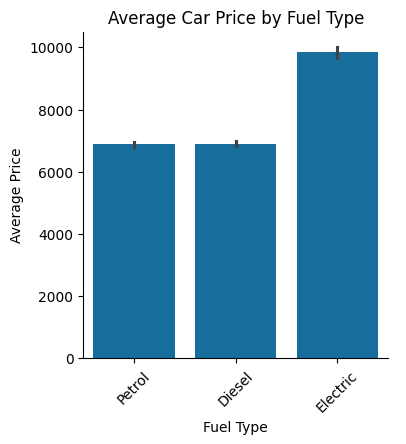

Electric cars average price: 9839.48

Non - Electric cars (Petrol and Diesel) average price: 6892.74 

There are 974 Electric cars out of 10000


In [10]:
ax = sns.catplot(data=df, x='fuel_type',y='price_usd',kind='bar',height=4,aspect=1)
ax.set(title='Average Car Price by Fuel Type', xlabel='Fuel Type', ylabel='Average Price')
plt.xticks(rotation=45)
plt.show()

# Average price of electric cars
mean_electric = df[df['fuel_type'] == 'Electric']['price_usd'].mean()

# Number of electric cars
sum_electric = df[df['fuel_type'] == 'Electric'].shape[0]

# Average price of non-electric cars (Petrol or Diesel)
mean_non_electric = df[df['fuel_type'].isin(['Petrol', 'Diesel'])]['price_usd'].mean()

print(f"Electric cars average price: {mean_electric:.2f}")
print(f"\nNon - Electric cars (Petrol and Diesel) average price: {mean_non_electric:.2f} ")
print(f"\nThere are {sum_electric} Electric cars out of 10000")

**Note:** Only about 9.7% of the cars in the dataset are Electric. This might not reflect their share of the population, and their rarity might even explain the higher price.

### Hypothesis Test #2: Does Transmission Type Affect Car Price?

In this test, I determine whether transmission type has a direct relationship with car price.

This question is of interest because this variable can potentially help predict a car's price based on factors I believe are important when purchasing a vehicle.

$H_0$ : There is no relation between transmission type and car price
$H_1$ : There is a relation between transmission type and car price

I use a bootstrap method to compute a 95% confidence interval for the difference between the transmission type means.

**Test statistic:**

Since there are 2 groups, I check the difference between their means:

(Automatic mean) - (Manual mean)

Hypothesis Test Results:
         Comparison Observed Diff in Means (Automatic - Manual) 95% Confidence Interval P-value
Automatic vs Manual                                      $15.80      [$-92.33, $124.61]  0.7750


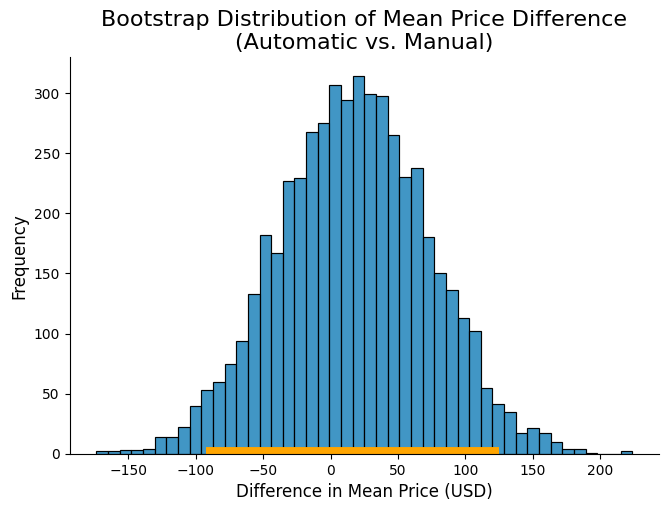

In [ ]:
# Test settings
COLUMN_TO_TEST = 'price_usd'
GROUPING_VARIABLE = 'transmission'
GROUP_1 = 'Automatic'
GROUP_2 = 'Manual'
NUM_REPS = 5000

sub_df = df.copy()

sub_df[GROUPING_VARIABLE] = pd.Categorical(sub_df[GROUPING_VARIABLE], categories=[GROUP_2, GROUP_1], ordered=True)

# Observed difference in means
obs_diff = diff_of_avgs(sub_df, COLUMN_TO_TEST, GROUPING_VARIABLE)

# Bootstrap distribution of the mean differences
bstrap_diffs = bootstrap_mean_difference(
    original_sample=sub_df,
    column_name=COLUMN_TO_TEST,
    grouping_var=GROUPING_VARIABLE,
    num_replications=NUM_REPS
)

# 95% confidence interval
left_end = np.percentile(bstrap_diffs, 2.5)
right_end = np.percentile(bstrap_diffs, 97.5)

# P-value: the bootstrap distribution is centered at the observed difference, so shift it to be
# centered at 0 (the null hypothesis) and count how often a difference at least as extreme appears
null_diffs = bstrap_diffs - obs_diff
p_value = np.mean(np.abs(null_diffs) >= np.abs(obs_diff))

# Summary table
results = {
    'Comparison': f'{GROUP_1} vs {GROUP_2}',
    'Observed Diff in Means (Automatic - Manual)': f'${obs_diff:,.2f}',
    '95% Confidence Interval': f'[${left_end:,.2f}, ${right_end:,.2f}]',
    'P-value': f'{p_value:.4f}'
}
results_df = pd.DataFrame([results])
print("Hypothesis Test Results:")
print(results_df.to_string(index=False))

# Plot the bootstrap distribution with the confidence interval
ax = sns.displot(bstrap_diffs, height=4.5, aspect=1.5)
plt.hlines(y=0, xmin=left_end, xmax=right_end,
            colors='orange', linestyles='solid', lw=10, label='95% Confidence Interval')

plt.title(f'Bootstrap Distribution of Mean Price Difference\n({GROUP_1} vs. {GROUP_2})', fontsize=16)
plt.xlabel(f'Difference in Mean Price (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### Bootstrap Results

The 95% confidence interval for the difference in mean prices **includes 0** and the p-value is large, so I cannot reject the null hypothesis that there is no relation between transmission type and price.

**Conclusion:** I cannot reject the null hypothesis. There is no evidence that transmission type affects price.

To see the results more clearly, I plot the average car price per transmission type.

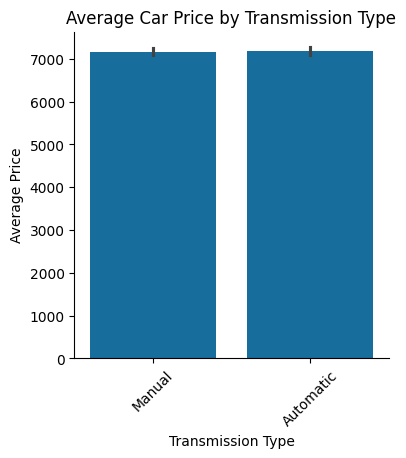

Manual cars average price: 7173.41

Automatic cars average price: 7189.21 

There are 5985 Manual cars out of 10000


In [12]:
ax = sns.catplot(data=df, x='transmission',y='price_usd',kind='bar',height=4,aspect=1)
ax.set(title='Average Car Price by Transmission Type', xlabel='Transmission Type', ylabel='Average Price')
plt.xticks(rotation=45)
plt.show()

# Average price of manual cars
mean_manual = df[df['transmission'] == 'Manual']['price_usd'].mean()

# Number of manual cars
sum_manual = df[df['transmission'] == 'Manual'].shape[0]

# Average price of automatic cars
mean_auto = df[df['transmission'] == 'Automatic']['price_usd'].mean()

print(f"Manual cars average price: {mean_manual:.2f}")
print(f"\nAutomatic cars average price: {mean_auto:.2f} ")
print(f"\nThere are {sum_manual} Manual cars out of 10000")

## Classification

The most immediate classification task that comes to mind is classifying the price of a car as "Budget", "Mid-Range" or "Expensive".

I need to choose features for the classification task, but I do not want to choose them based on the test set, so I split the data and put aside a test set before doing any feature selection.
First, though, some preprocessing is needed to handle the categorical variables.

There are no missing values left, since the missing values in *service_history* were already replaced.

### Creating Price Classes

First, I create the price classes and drop the original *price_usd* column to prevent leakage.

In [13]:
# Split the continuous price into 3 equal-sized bins, stored as integers (as KNN expects):
#   0 - Budget (bottom third)
#   1 - Mid-Range (middle third)
#   2 - Expensive (top third)
df['price_bracket'] = pd.qcut(df['price_usd'], q=3, labels=[0, 1, 2]).astype(int)

# Price range and number of cars in each bin
ranges = pd.qcut(df['price_usd'], q=3).cat.categories
counts = df['price_bracket'].value_counts().sort_index()

print(f"Budget price range [{ranges[0].left:.0f}, {ranges[0].right:.0f}] - {counts[0]} cars")
print(f"Mid-Range price range [{ranges[1].left:.0f}, {ranges[1].right:.0f}] - {counts[1]} cars")
print(f"Expensive price range [{ranges[2].left:.0f}, {ranges[2].right:.0f}] - {counts[2]} cars")


# Remove price_usd to prevent leakage
df = df.drop(columns=['price_usd'])
target = 'price_bracket'

Budget price range [1000, 5826] - 3333 cars
Mid-Range price range [5826, 8225] - 3333 cars
Expensive price range [8225, 17648] - 3334 cars


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   brand               10000 non-null  object 
 6   transmission        10000 non-null  object 
 7   color               10000 non-null  object 
 8   service_history     10000 non-null  object 
 9   accidents_reported  10000 non-null  int64  
 10  insurance_valid     10000 non-null  object 
 11  price_bracket       10000 non-null  int32  
dtypes: float64(1), int32(1), int64(4), object(6)
memory usage: 898.6+ KB


### Encoding Categorical Features

The categorical features are:

- *fuel_type*
- *brand*
- *transmission*
- *color*
- *insurance_valid*
- *service_history*

All of these features except *service_history* are nominal, so I use `pd.get_dummies` (one-hot encoding) for them.

*service_history* is ordinal (None < Partial < Full), so I map it to the integers 1, 2 and 3.

In [15]:
# One-hot encoding
encoded_df = pd.get_dummies(df,
                                columns=['fuel_type', 'brand', 'transmission', 'color', 'insurance_valid'], drop_first=True)
encoded_df.head()

,make_year,mileage_kmpl,engine_cc,owner_count,service_history,accidents_reported,price_bracket,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,...,brand_Tesla,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes
0,2001,8.17,4000,4,None,0,2,False,True,True,...,False,False,False,True,False,False,False,False,True,False
1,2014,17.59,1500,4,None,0,1,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,2023,18.09,2500,5,Full,1,2,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2009,11.28,800,1,Full,0,1,False,True,False,...,False,False,False,True,True,False,False,False,False,True
4,2005,12.23,1000,2,Full,0,0,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [16]:
# Ordinal encoding of service_history
encoded_df['service_history'] = encoded_df['service_history'].map({'None': 1, 'Partial': 2, 'Full': 3})
encoded_df["service_history"] = encoded_df["service_history"].astype(int)
encoded_df.head()

,make_year,mileage_kmpl,engine_cc,owner_count,service_history,accidents_reported,price_bracket,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,...,brand_Tesla,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes
0,2001,8.17,4000,4,1,0,2,False,True,True,...,False,False,False,True,False,False,False,False,True,False
1,2014,17.59,1500,4,1,0,1,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,2023,18.09,2500,5,3,1,2,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2009,11.28,800,1,3,0,1,False,True,False,...,False,False,False,True,True,False,False,False,False,True
4,2005,12.23,1000,2,3,0,0,False,True,False,...,False,False,False,False,False,False,True,False,False,True


### Train-Test Split

Next, I:
- Split the dataset into train and test sets (80% train, 20% test)
- Scale the features (done later, after feature selection, using `StandardScaler`)

In [17]:
from sklearn.model_selection import train_test_split

# Shuffle the dataframe
encoded_df = encoded_df.sample(frac=1, random_state=SEED)

# Make sure price_bracket exists
assert 'price_bracket' in encoded_df.columns

Y = encoded_df['price_bracket']
X = encoded_df.drop(columns=['price_bracket'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=SEED)

### Feature Selection

I want to use only the features that are useful for distinguishing between the classes, because features that aren't might add noise to the classifier.

I examine the correlation of each feature with the target variable, *price_bracket*. Features that correlate strongly with the target, whether negatively or positively, are a good match.

I visualize the correlations using a heatmap.

In [18]:
# Combine the training features and target to compute correlations
train_data = pd.concat([X_train, Y_train], axis=1)
train_data.corr()

,make_year,mileage_kmpl,engine_cc,owner_count,service_history,accidents_reported,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,brand_Ford,...,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes,price_bracket
make_year,1.000000,-0.008440,-0.017642,-0.011243,-0.000108,0.000100,-0.010625,0.014778,0.010334,0.002975,...,0.009170,0.003160,0.004846,0.006355,0.003294,0.011895,-0.015074,-0.000463,0.005156,0.392712
mileage_kmpl,-0.008440,1.000000,-0.000012,-0.006811,-0.007640,0.013393,0.009978,-0.004991,-0.016624,-0.007845,...,-0.005281,0.003888,-0.004166,0.011038,-0.001222,0.001202,-0.015571,-0.008645,0.004768,0.192821
engine_cc,-0.017642,-0.000012,1.000000,-0.002602,0.011196,-0.003054,-0.009767,0.000518,0.000569,0.022974,...,-0.008438,0.003620,0.001360,0.006889,0.008161,0.006700,-0.009834,-0.021446,-0.017586,0.606218
owner_count,-0.011243,-0.006811,-0.002602,1.000000,-0.036738,-0.014704,-0.002029,0.006968,-0.000869,0.013878,...,-0.013641,0.001744,0.014164,0.007386,-0.010451,-0.010655,0.007473,0.007993,0.000245,-0.228607
service_history,-0.000108,-0.007640,0.011196,-0.036738,1.000000,0.023598,0.012491,-0.004905,-0.016379,-0.020420,...,0.029923,-0.001461,0.024574,-0.018096,-0.017485,0.012548,-0.006620,0.015297,-0.002152,0.011949
accidents_reported,0.000100,0.013393,-0.003054,-0.014704,0.023598,1.000000,0.010745,0.000541,-0.006496,-0.030797,...,-0.004290,-0.008826,0.003443,0.004313,0.004086,-0.016187,-0.011539,0.005767,-0.018443,0.008456
fuel_type_Electric,-0.010625,0.009978,-0.009767,-0.002029,0.012491,0.010745,1.000000,-0.333583,-0.008554,0.006195,...,-0.013515,-0.016228,0.013510,-0.003378,-0.024235,0.031539,-0.008732,0.010272,0.005454,0.265765
fuel_type_Petrol,0.014778,-0.004991,0.000518,0.006968,-0.004905,0.000541,-0.333583,1.000000,0.012993,-0.004129,...,-0.001091,0.011299,-0.003718,0.005073,-0.007372,-0.011666,0.022466,-0.010384,-0.004866,-0.090054
brand_Chevrolet,0.010334,-0.016624,0.000569,-0.000869,-0.016379,-0.006496,-0.008554,0.012993,1.000000,-0.107066,...,-0.110158,-0.113430,-0.006138,0.005632,0.009202,0.020262,0.000416,-0.011986,0.000797,-0.003703
brand_Ford,0.002975,-0.007845,0.022974,0.013878,-0.020420,-0.030797,0.006195,-0.004129,-0.107066,1.000000,...,-0.104404,-0.107505,-0.010092,-0.004303,0.004436,0.004698,-0.019487,0.012435,-0.002901,0.018909


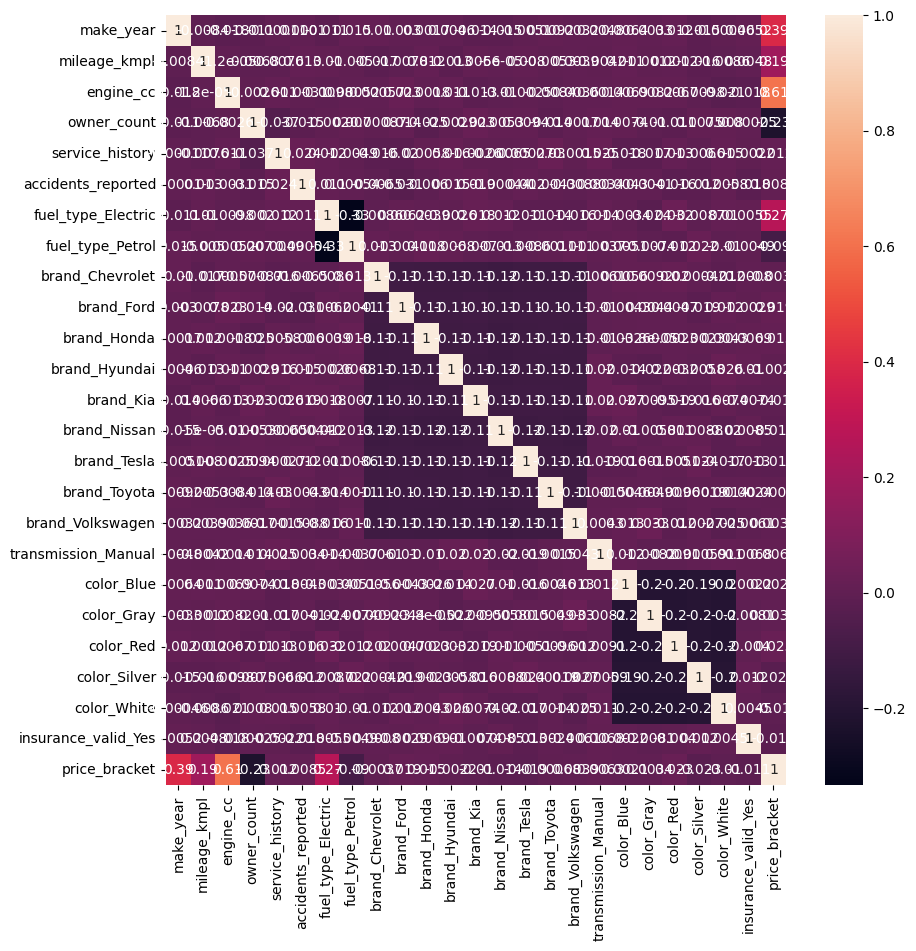

In [19]:
# Correlation between each pair of variables
correlations = train_data.corr()

# Plot the heatmap
plt.figure(figsize=(10,10))
sns.heatmap(correlations, annot=True)
plt.show()

The heatmap is very cluttered, which suggests a lot of noise.

To reduce some of that noise, I drop a less relevant feature, *color*, which most likely has little effect on price.

Although *brand* adds many dimensions, I keep it because in reality it can significantly influence price. For example, BMWs are more likely to fall within the "Expensive" price range.

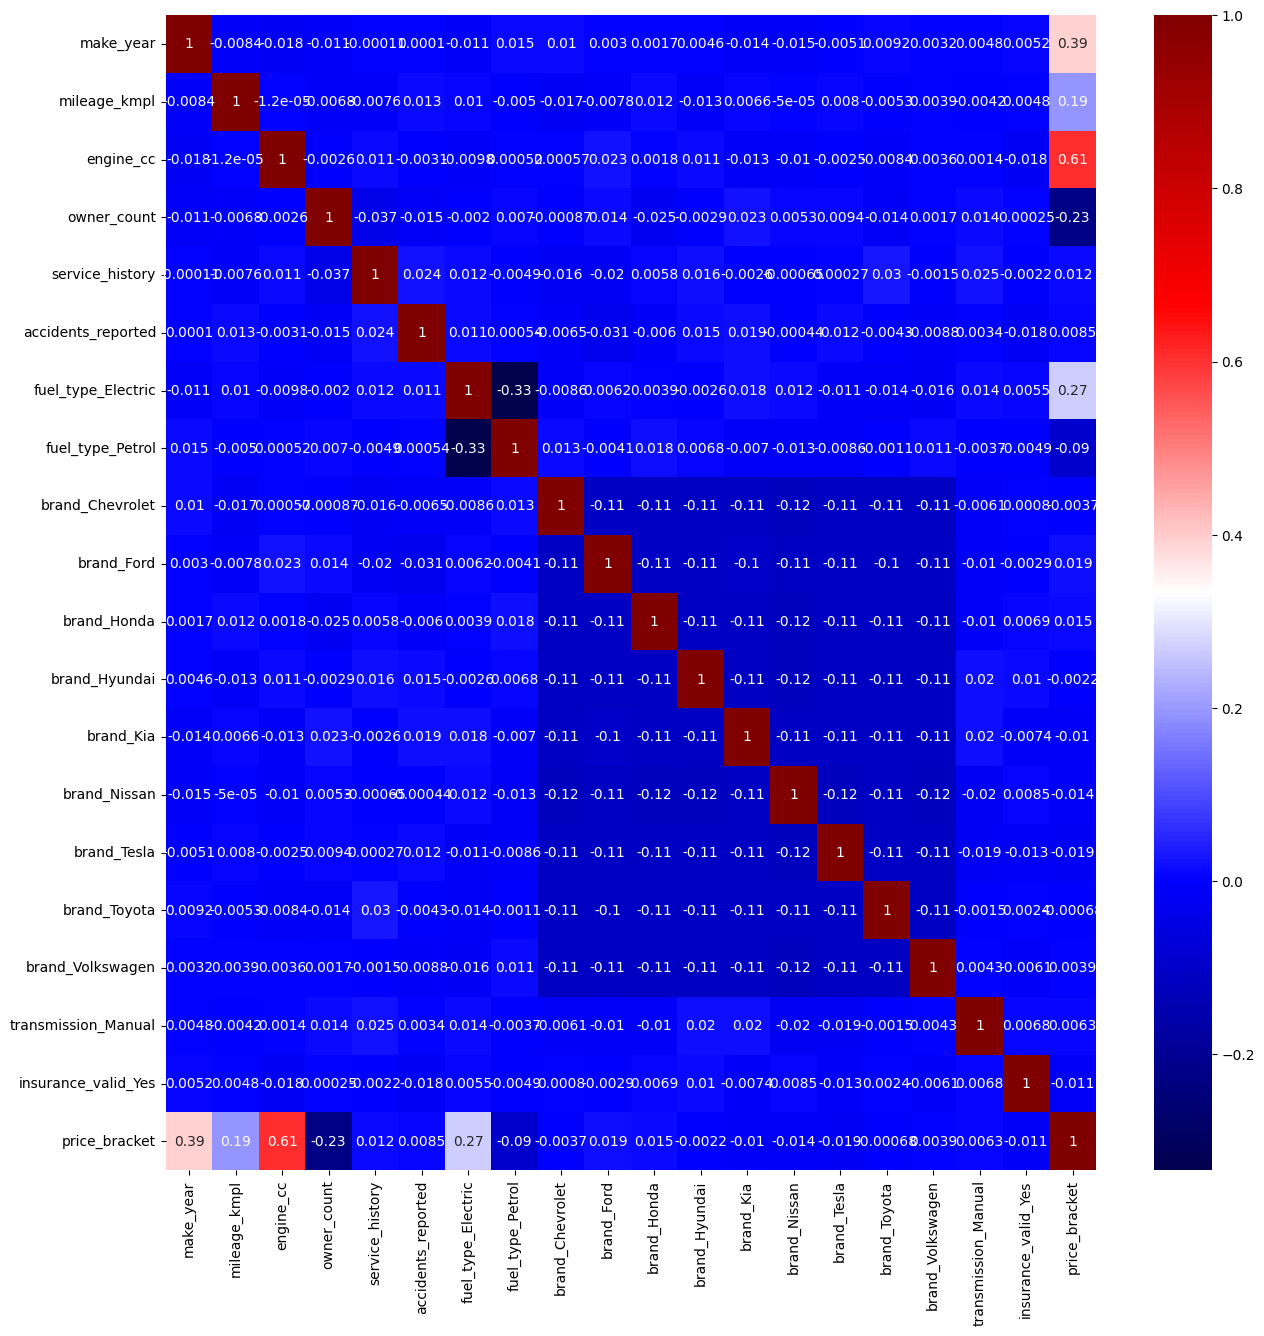

In [20]:
# Drop color and repeat the encoding, split and correlation steps
encoded_df = df.drop(columns=['color'])

encoded_df = pd.get_dummies(encoded_df,
                                columns=['fuel_type', 'brand', 'transmission', 'insurance_valid'], drop_first=True)

encoded_df['service_history'] = encoded_df['service_history'].map({'None': 1, 'Partial': 2, 'Full': 3})
encoded_df["service_history"] = encoded_df["service_history"].astype(int)

# Shuffle the dataframe
encoded_df = encoded_df.sample(frac=1, random_state=SEED)

# Make sure price_bracket exists
assert 'price_bracket' in encoded_df.columns

Y = encoded_df['price_bracket']
X = encoded_df.drop(columns=['price_bracket'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=SEED)



train_data = pd.concat([X_train, Y_train], axis=1)


# Correlation between each pair of variables
correlations = train_data.corr()

# Plot the heatmap
plt.figure(figsize=(15,15))
sns.heatmap(correlations, annot=True, cmap="seismic")
plt.show()

In [21]:
correlations.reindex(correlations["price_bracket"].abs().sort_values().index)["price_bracket"]  # Sorted by absolute correlation

brand_Toyota          -0.000685
brand_Hyundai         -0.002184
brand_Chevrolet       -0.003703
brand_Volkswagen       0.003907
transmission_Manual    0.006314
accidents_reported     0.008456
brand_Kia             -0.010028
insurance_valid_Yes   -0.011158
service_history        0.011949
brand_Nissan          -0.014455
brand_Honda            0.014661
brand_Tesla           -0.018563
brand_Ford             0.018909
fuel_type_Petrol      -0.090054
mileage_kmpl           0.192821
owner_count           -0.228607
fuel_type_Electric     0.265765
make_year              0.392712
engine_cc              0.606218
price_bracket          1.000000
Name: price_bracket, dtype: float64

From this correlation list, I keep only the features with the highest correlation with price, and drop the ones with the lowest correlation, since they are likely to add noise.

In [22]:
# Keep only the selected features (in both the train and test sets)
selected_features = ['engine_cc', 'make_year', 'owner_count', 'mileage_kmpl', 'fuel_type_Electric',
                     'fuel_type_Petrol']

X_train = X_train[selected_features]
display(X_train)

X_test = X_test[selected_features]
X_test

,engine_cc,make_year,owner_count,mileage_kmpl,fuel_type_Electric,fuel_type_Petrol
3900,1500,2018,3,22.48,False,True
3643,1800,2019,5,13.77,False,False
5623,800,1998,2,22.19,False,True
3824,4000,2000,2,12.46,False,True
5880,1800,2008,4,21.82,False,False
...,...,...,...,...,...,...
6553,800,2021,4,5.83,False,True
5958,1000,2023,5,22.94,False,False
6264,1000,2005,4,18.08,False,True
9115,2000,2004,4,17.96,False,False


,engine_cc,make_year,owner_count,mileage_kmpl,fuel_type_Electric,fuel_type_Petrol
7217,1800,2010,4,18.18,False,True
8291,3000,1999,3,21.77,False,False
4607,2000,1995,4,23.07,False,False
5114,1500,2003,2,14.72,False,False
1859,4000,1997,2,8.54,False,True
...,...,...,...,...,...,...
3800,1800,2002,3,19.40,False,False
8510,4000,2006,4,23.15,False,True
1668,3000,2016,5,12.87,False,False
2685,1000,2009,5,17.69,False,True


In [23]:
# Standardize the features using z-scores. KNN is a distance-based algorithm, so without standardization,
# features with larger numeric ranges would dominate the distance metric. Giving each feature a mean of 0
# and a standard deviation of 1 makes all features contribute equally to the neighbor search
from sklearn.preprocessing import StandardScaler
df_columns = X_train.columns
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)

scaled_X_test = scaler.transform(X_test)

scaled_df = pd.DataFrame(scaled_X_train, columns=df_columns)
scaled_df.describe()

,engine_cc,make_year,owner_count,mileage_kmpl,fuel_type_Electric,fuel_type_Petrol
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,9.769963e-18,-1.017320e-14,3.552714e-17,-3.592682e-16,-4.707346e-17,3.108624e-18
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-1.146765e+00,-1.694468e+00,-1.416126e+00,-2.593737e+00,-3.333333e-01,-1.000750e+00
25%,-8.363038e-01,-8.615353e-01,-7.102248e-01,-6.774085e-01,-3.333333e-01,-1.000750e+00
50%,-3.706126e-01,-2.860232e-02,-4.323645e-03,8.709245e-03,-3.333333e-01,9.992503e-01
75%,5.607698e-01,9.233211e-01,7.015775e-01,6.728232e-01,-3.333333e-01,9.992503e-01
max,2.113074e+00,1.637264e+00,1.407479e+00,3.405292e+00,3.000000e+00,9.992503e-01


Highest accuracy is obtained for k = 38 and equals 0.7665000000000001


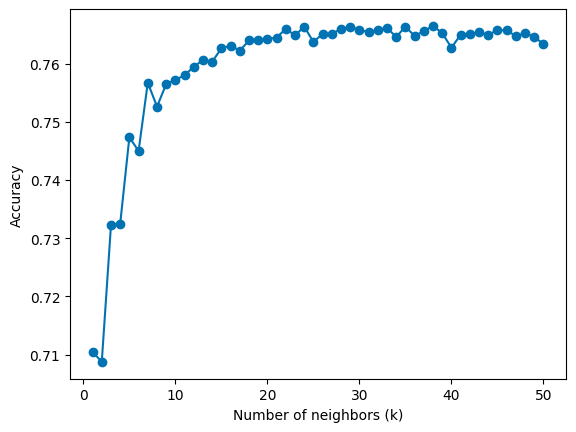

In [24]:
# 10-fold cross-validation on the training data only, to find the best k
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

mean_cv_scores = []
k_list = range(1, 51)
for nn in k_list:
    knn_cv = KNeighborsClassifier(n_neighbors=nn)
    cv_scores = cross_val_score(knn_cv, scaled_X_train, Y_train, cv=10)
    mean_cv_scores.append(cv_scores.mean())

# Output results
best_k = k_list[int(np.argmax(mean_cv_scores))]  # The k with the highest mean CV accuracy
print('Highest accuracy is obtained for k =', best_k, 'and equals', max(mean_cv_scores))
plt.plot(k_list, mean_cv_scores, '-o')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Accuracy');

In [25]:
# Retrain KNN with the best k on the whole training set and evaluate it on the test set
# The confusion matrix, precision and recall are adjusted for 3 classes instead of 2
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

knn_classifier = KNeighborsClassifier(n_neighbors=best_k)
knn_classifier.fit(scaled_X_train, Y_train)
print('accuracy of the classifier is', knn_classifier.score(scaled_X_test, Y_test))

# Confusion matrix
predictions = knn_classifier.predict(X=scaled_X_test)  # The classifier's predictions
print('confusion matrix: \n', confusion_matrix(y_true=Y_test, y_pred=predictions, labels=[0, 1, 2]))  # Rows are true values, columns are predicted values

# Precision and recall, macro-averaged over the 3 classes
print('precision: ', precision_score(y_true=Y_test, y_pred=predictions, average='macro'))
print('recall: ', recall_score(y_true=Y_test, y_pred=predictions, average='macro'))

accuracy of the classifier is 0.7735
confusion matrix: 
 [[548 124   2]
 [118 458  68]
 [  2 139 541]]
precision:  0.780340615159719
recall:  0.7724972120034567


### Using Fewer Features

Based on the results so far, I believe it may be possible to achieve a higher accuracy by using fewer dimensions.

Below, I put this hypothesis to the test.

In [26]:
# Keep only the 4 features with the highest correlation (in both the train and test sets)
selected_features = ['engine_cc', 'make_year', 'owner_count', 'fuel_type_Electric']

X_train = X_train[selected_features]
display(X_train)

X_test = X_test[selected_features]
X_test

,engine_cc,make_year,owner_count,fuel_type_Electric
3900,1500,2018,3,False
3643,1800,2019,5,False
5623,800,1998,2,False
3824,4000,2000,2,False
5880,1800,2008,4,False
...,...,...,...,...
6553,800,2021,4,False
5958,1000,2023,5,False
6264,1000,2005,4,False
9115,2000,2004,4,False


,engine_cc,make_year,owner_count,fuel_type_Electric
7217,1800,2010,4,False
8291,3000,1999,3,False
4607,2000,1995,4,False
5114,1500,2003,2,False
1859,4000,1997,2,False
...,...,...,...,...
3800,1800,2002,3,False
8510,4000,2006,4,False
1668,3000,2016,5,False
2685,1000,2009,5,False


In [27]:
# Standardize the features using z-scores (same as above)
from sklearn.preprocessing import StandardScaler
df_columns = X_train.columns
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)

scaled_X_test = scaler.transform(X_test)

scaled_df = pd.DataFrame(scaled_X_train, columns=df_columns)
scaled_df.describe()

,engine_cc,make_year,owner_count,fuel_type_Electric
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,9.769963e-18,-1.017320e-14,3.552714e-17,-4.707346e-17
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-1.146765e+00,-1.694468e+00,-1.416126e+00,-3.333333e-01
25%,-8.363038e-01,-8.615353e-01,-7.102248e-01,-3.333333e-01
50%,-3.706126e-01,-2.860232e-02,-4.323645e-03,-3.333333e-01
75%,5.607698e-01,9.233211e-01,7.015775e-01,-3.333333e-01
max,2.113074e+00,1.637264e+00,1.407479e+00,3.000000e+00


Highest accuracy is obtained for k = 29 and equals 0.74325


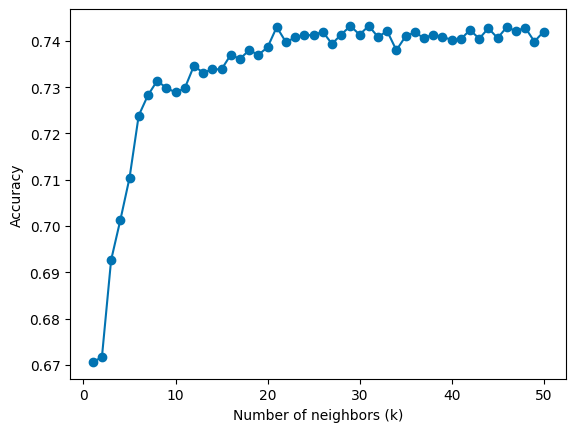

In [28]:
# 10-fold cross-validation on the training data only, to find the best k
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

mean_cv_scores = []
k_list = range(1, 51)
for nn in k_list:
    knn_cv = KNeighborsClassifier(n_neighbors=nn)
    cv_scores = cross_val_score(knn_cv, scaled_X_train, Y_train, cv=10)
    mean_cv_scores.append(cv_scores.mean())

# Output results
best_k = k_list[int(np.argmax(mean_cv_scores))]  # The k with the highest mean CV accuracy
print('Highest accuracy is obtained for k =', best_k, 'and equals', max(mean_cv_scores))
plt.plot(k_list, mean_cv_scores, '-o')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Accuracy');

In [29]:
# Retrain KNN with the best k on the whole training set and evaluate it on the test set
# The confusion matrix, precision and recall are adjusted for 3 classes instead of 2
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

knn_classifier = KNeighborsClassifier(n_neighbors=best_k)
knn_classifier.fit(scaled_X_train, Y_train)
print('accuracy of the classifier is', knn_classifier.score(scaled_X_test, Y_test))

# Confusion matrix
predictions = knn_classifier.predict(X=scaled_X_test)  # The classifier's predictions
print('confusion matrix: \n', confusion_matrix(y_true=Y_test, y_pred=predictions, labels=[0, 1, 2]))  # Rows are true values, columns are predicted values

# Precision and recall, macro-averaged over the 3 classes
print('precision: ', precision_score(y_true=Y_test, y_pred=predictions, average='macro'))
print('recall: ', recall_score(y_true=Y_test, y_pred=predictions, average='macro'))

accuracy of the classifier is 0.749
confusion matrix: 
 [[533 137   4]
 [136 409  99]
 [  3 123 556]]
precision:  0.7494058602446175
recall:  0.7470478738358847


**Conclusion:** Reducing the number of dimensions resulted in a slight loss of accuracy, but it did lead to faster computation, which can be advantageous depending on the task.

In this case, higher accuracy is a greater priority than reducing computation time, so I consider the original classifier (with 6 features) to be the better choice.

## Regression

The classification model predicts which price range a car belongs to. In this section, I go one step further and try to predict the **exact** price (*price_usd*) of a car. A possible application is an automatic price estimate for people selling or buying a used car.

**Decisions:**
- **Target:** *price_usd* (continuous).
- **Features:** all features except *color*, which I already found to be irrelevant to price in the classification section.
- **Encoding:** the same as in the classification section - one-hot encoding for the nominal features and ordinal encoding for *service_history*.
- **Split:** 80% train, 20% test. All decisions (feature selection, choosing k) are made using the training set only.
- **Models:** linear regression and KNN regression, both compared to a simple baseline.

**Alternatives I could have chosen:** predicting the log of the price (useful when the price is very skewed, which is not the case here), or regularized linear models such as Ridge or Lasso (useful when there are many correlated features, which is also not the case here).

Since the classification section dropped *price_usd* from `df`, I reload the dataset.

In [30]:
# Reload the dataset, since price_usd was dropped in the classification section
reg_df = pd.read_csv("used_car_price_dataset_extended.csv")
reg_df = reg_df.fillna("None")

# Drop color, as in the classification section
reg_df = reg_df.drop(columns=['color'])

# One-hot encoding of the nominal features
reg_df = pd.get_dummies(reg_df, columns=['fuel_type', 'brand', 'transmission', 'insurance_valid'], drop_first=True)

# Ordinal encoding of service_history
reg_df['service_history'] = reg_df['service_history'].map({'None': 1, 'Partial': 2, 'Full': 3})
reg_df['service_history'] = reg_df['service_history'].astype(int)

Y_reg = reg_df['price_usd']
X_reg = reg_df.drop(columns=['price_usd'])

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(X_reg, Y_reg, test_size=0.20, random_state=SEED)
print('Train set:', X_train_reg.shape, '| Test set:', X_test_reg.shape)

Train set: (8000, 19) | Test set: (2000, 19)


### Feature Correlation with Price

As in the classification section, I examine the correlation of each feature with the target, this time with the continuous *price_usd*, using the training set only.

In [31]:
# Correlation of each feature with price_usd, using the training set only
train_data_reg = pd.concat([X_train_reg, Y_train_reg], axis=1)
reg_correlations = train_data_reg.corr()['price_usd']
reg_correlations.reindex(reg_correlations.abs().sort_values().index)  # Sorted by absolute correlation

accidents_reported     0.001509
brand_Volkswagen       0.005293
transmission_Manual   -0.007325
brand_Kia             -0.007353
insurance_valid_Yes   -0.007759
brand_Honda            0.008601
service_history        0.009319
brand_Chevrolet        0.009580
brand_Toyota          -0.009832
brand_Hyundai         -0.010431
brand_Nissan          -0.011068
brand_Tesla           -0.014155
brand_Ford             0.018986
fuel_type_Petrol      -0.106014
mileage_kmpl           0.210747
owner_count           -0.265451
fuel_type_Electric     0.307052
make_year              0.428467
engine_cc              0.676312
price_usd              1.000000
Name: price_usd, dtype: float64

The ranking is very similar to the one in the classification section: *engine_cc*, *make_year*, *fuel_type_Electric*, *owner_count*, *mileage_kmpl* and *fuel_type_Petrol* have the highest correlation with price, while the other features are close to 0.

### Baseline

To judge whether a model is actually useful, I compare it to a baseline that ignores all features and always predicts the average price of the training set. A good model should do much better than this baseline.

I will evaluate the models with 3 metrics on the test set:
- **R²** - the share of the variance in price that the model explains (1 is perfect, 0 is as good as the baseline)
- **RMSE** - the typical prediction error in USD, with large errors weighted more heavily
- **MAE** - the average absolute prediction error in USD

In [32]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Return the R², RMSE and MAE of the predictions
def regression_metrics(y_true, y_pred):
    return {
        'R²': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }


# Baseline: predict the average training price for every car
baseline_predictions = np.full(len(Y_test_reg), Y_train_reg.mean())
baseline_metrics = regression_metrics(Y_test_reg, baseline_predictions)
print('Baseline:', {name: round(value, 3) for name, value in baseline_metrics.items()})

Baseline: {'R²': -0.001, 'RMSE': 2821.766, 'MAE': 2265.524}


### Linear Regression

Linear regression models the price as a weighted sum of the features. I fit it on all the encoded features without scaling, so each coefficient can be read directly as "the change in price (USD) for a one-unit increase in the feature, when all other features stay the same".

In [33]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_reg, Y_train_reg)

# Evaluate on the test set
linear_predictions = linear_model.predict(X_test_reg)
linear_metrics = regression_metrics(Y_test_reg, linear_predictions)
print('Linear regression:', {name: round(value, 3) for name, value in linear_metrics.items()})

# Coefficients, sorted by absolute size
coefficients = pd.Series(linear_model.coef_, index=X_train_reg.columns)
coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

Linear regression: {'R²': 0.877, 'RMSE': 989.819, 'MAE': 790.652}


fuel_type_Electric     3015.990817
owner_count            -489.419238
make_year               148.784372
mileage_kmpl            120.824529
brand_Tesla            -108.768773
brand_Hyundai           -87.902376
brand_Chevrolet         -80.101718
brand_Ford              -79.326770
brand_Toyota            -68.142956
brand_Kia               -62.739994
brand_Nissan            -58.358628
brand_Honda             -41.595708
insurance_valid_Yes     -35.635216
brand_Volkswagen        -16.810591
transmission_Manual     -13.435574
service_history         -12.626763
fuel_type_Petrol         -4.168945
accidents_reported        4.148847
engine_cc                 1.494262
dtype: float64

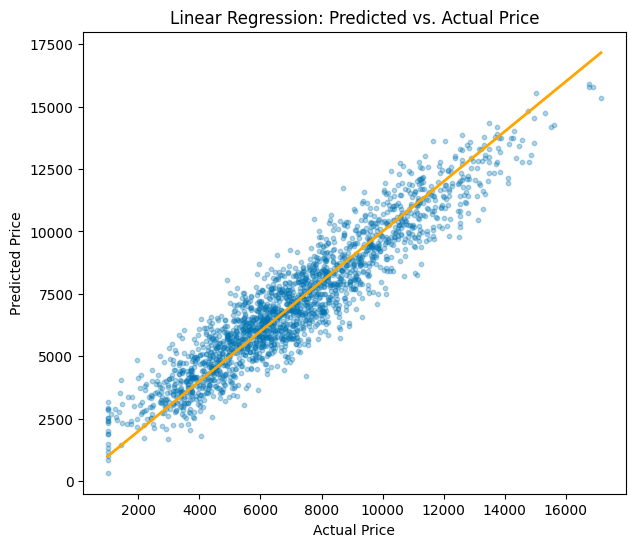

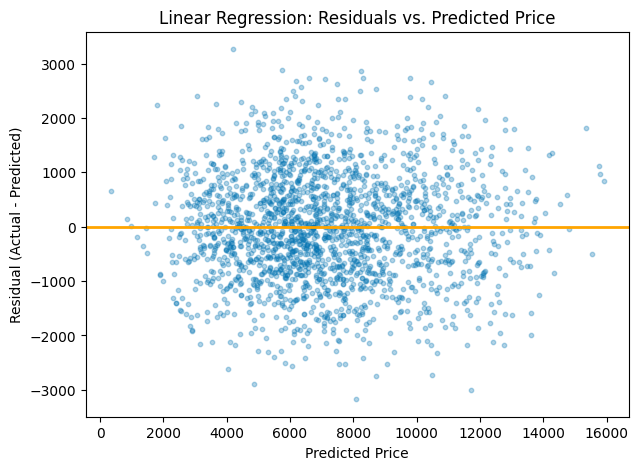

In [34]:
# Predicted vs. actual price, with the line of perfect predictions
plt.figure(figsize=(7, 6))
plt.scatter(Y_test_reg, linear_predictions, alpha=0.3, s=10)
plt.plot([Y_test_reg.min(), Y_test_reg.max()], [Y_test_reg.min(), Y_test_reg.max()], color='orange', lw=2)
plt.title('Linear Regression: Predicted vs. Actual Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

# Residuals vs. predicted price
residuals = Y_test_reg - linear_predictions
plt.figure(figsize=(7, 5))
plt.scatter(linear_predictions, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='orange', lw=2)
plt.title('Linear Regression: Residuals vs. Predicted Price')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()

**Interpreting the linear model:**

- The model explains about 88% of the variance in price (R² ≈ 0.88), with a typical error of about $1,000, compared to about $2,800 for the baseline.
- **Fuel type:** an Electric car costs about $3,000 more than a Diesel car (the reference category) with the same other features, while Petrol and Diesel cars are priced almost the same. This matches the results of the hypothesis test.
- **Owner count:** every additional previous owner lowers the price by about $490.
- **Make year:** every year newer adds about $150 to the price.
- **Engine capacity:** every additional cc adds about $1.5, which is about $1,500 per 1,000cc. The coefficient looks small only because *engine_cc* values are in the thousands.
- **Mileage:** every additional km/l adds about $120.
- **Brand, transmission, insurance, service history and accidents** have small coefficients, in line with their near-zero correlation with price. Interestingly, this means that in this dataset brand barely affects price, even though I expected it to (see the classification section).

The points in the predicted vs. actual plot are spread evenly around the line of perfect predictions, and the residuals look randomly scattered around 0 with no clear pattern. This suggests that a linear model fits this data well.

### KNN Regression

KNN regression predicts the price of a car as the average price of its k nearest neighbors in the training set. As in the classification section:
- I use only the 6 features with the highest correlation with price, since irrelevant features add noise to the distance calculation.
- I standardize the features, so features with larger numeric ranges don't dominate the distance.
- I choose k using 10-fold cross-validation on the training set only, this time minimizing the RMSE.

Lowest RMSE is obtained for k = 19 and equals 1075.61


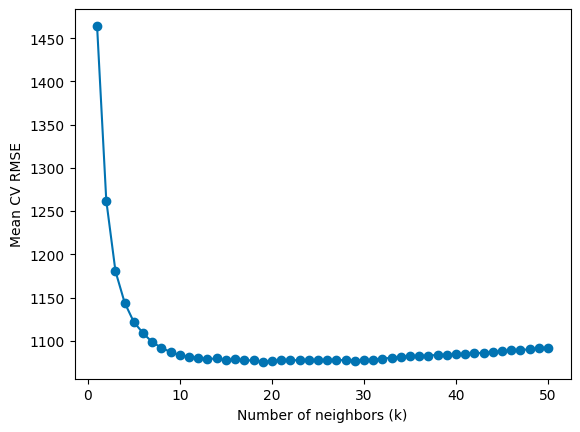

In [35]:
from sklearn.neighbors import KNeighborsRegressor

# Keep only the 6 features with the highest correlation with price (in both the train and test sets)
reg_selected_features = ['engine_cc', 'make_year', 'fuel_type_Electric', 'owner_count', 'mileage_kmpl', 'fuel_type_Petrol']

# Standardize the features using z-scores, fitted on the training set only
reg_scaler = StandardScaler()
scaled_X_train_reg = reg_scaler.fit_transform(X_train_reg[reg_selected_features])
scaled_X_test_reg = reg_scaler.transform(X_test_reg[reg_selected_features])

# 10-fold cross-validation on the training data only, to find the best k
mean_cv_rmse = []
k_list = range(1, 51)
for nn in k_list:
    knn_reg_cv = KNeighborsRegressor(n_neighbors=nn)
    cv_scores = cross_val_score(knn_reg_cv, scaled_X_train_reg, Y_train_reg, cv=10, scoring='neg_root_mean_squared_error')
    mean_cv_rmse.append(-cv_scores.mean())  # Scores are negative RMSE, so flip the sign

# Output results
best_k_reg = k_list[int(np.argmin(mean_cv_rmse))]  # The k with the lowest mean CV RMSE
print('Lowest RMSE is obtained for k =', best_k_reg, 'and equals', round(min(mean_cv_rmse), 2))
plt.plot(k_list, mean_cv_rmse, '-o')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Mean CV RMSE');

In [36]:
# Retrain KNN with the best k on the whole training set and evaluate it on the test set
knn_regressor = KNeighborsRegressor(n_neighbors=best_k_reg)
knn_regressor.fit(scaled_X_train_reg, Y_train_reg)

knn_predictions = knn_regressor.predict(scaled_X_test_reg)
knn_metrics = regression_metrics(Y_test_reg, knn_predictions)
print('KNN regression:', {name: round(value, 3) for name, value in knn_metrics.items()})

KNN regression: {'R²': 0.858, 'RMSE': 1063.078, 'MAE': 847.932}


### Model Comparison

In [37]:
# Test set metrics of all the models
comparison = pd.DataFrame(
    [baseline_metrics, linear_metrics, knn_metrics],
    index=['Baseline (mean)', 'Linear regression', f'KNN regression (k={best_k_reg})']
)
comparison.round(3)

,R²,RMSE,MAE
Baseline (mean),-0.001,2821.766,2265.524
Linear regression,0.877,989.819,790.652
KNN regression (k=19),0.858,1063.078,847.932


**Conclusion:** Both models are far better than the baseline, which confirms that the features carry real information about the price.

Linear regression performs best (R² ≈ 0.88, RMSE ≈ $990), slightly better than KNN regression (R² ≈ 0.86, RMSE ≈ $1,060). The linear model is also easier to interpret, since each coefficient shows how much a feature changes the price. Therefore, I consider linear regression to be the better choice for this task.

The fact that a simple linear model works this well suggests that price in this dataset depends on the features in an almost linear way. This is also why KNN, which is more flexible but has to estimate the price from nearby cars only, does not gain anything over it.

**Limitations:**
- The near-linear relationship, and the fact that brand barely affects price, suggest that the dataset may have been generated synthetically. Real used car prices are usually affected by brand and are less linear, so these results may not carry over to real-world data.
- About 12% of the variance in price remains unexplained by the available features. Other factors, such as the car's model, condition or the total kilometers driven, may explain part of it.